## How to use `generator_to_eq` function

We check the content of `generator_to_eq` function, which is used in the examples of `Example 3.9.` in the gEDMD paper "[Data-driven approximation of the Koopman generator: Model reduction, system identification, and control](https://www.sciencedirect.com/science/article/pii/S0167278919306086)" (P.7).

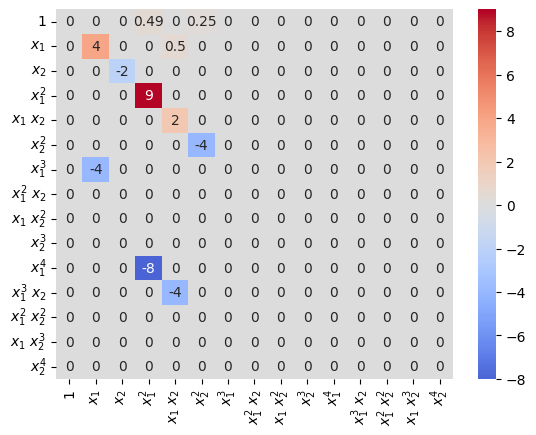

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt # If you don't have matplotlib, you can install it via pip: pip install matplotlib
import seaborn as sns           # If you don't have seaborn, you can install it via pip: pip install seaborn
from IPython.display import display
from ddsm.dicts import MonomialsDict
from ddsm.utils import generator_to_eq

psi = MonomialsDict(degree=4)
psi.dim_ = 2
psi.degrees_ = psi._generate_degrees()

right_L = np.zeros((len(psi), len(psi)), dtype=np.float64)
right_L[1, 1] = 4
right_L[6, 1] = -4
right_L[2, 2] = -2
right_L[0, 3] = 0.49
right_L[3, 3] = 9
right_L[10, 3] = -8
right_L[1, 4] = 0.5
right_L[4, 4] = 2
right_L[11, 4] = -4

right_L[0, 5] = 0.25
right_L[5, 5] = -4

def get_basis_labels(degrees):
    labels = []
    for d in degrees:
        if np.all(d == 0):
            labels.append("1")
            continue

        parts = []
        for i, p in enumerate(d):
            if p == 0:
                continue
            elif p == 1:
                parts.append(fr"$x_{i+1}$")
            else:
                parts.append(fr"$x_{i+1}^{int(p)}$")
        labels.append(" ".join(parts))
    return labels

basis_labels = get_basis_labels(psi.degrees)
sns.heatmap(right_L, annot=True, cmap='coolwarm', center=0, xticklabels=basis_labels, yticklabels=basis_labels)
plt.show()

In [2]:
eq = generator_to_eq(right_L, psi, threshold_drift=1.0e-2, threshold_diff=1.0e-2)
print('----- Drift Term -----')
display(eq.drift)
print('----- Diffusion Term -----')
display(eq.diff)

----- Drift Term -----


Matrix([
[-4.0*x1**3 + 4.0*x1],
[            -2.0*x2]])

----- Diffusion Term -----


Matrix([
[1.0*x1**2 + 0.49, 0.5*x1],
[          0.5*x1,   0.25]])